# 3-모델 성능 비교: MLP vs LightGBM vs SVM

각 모델의 평가 결과 파일(`*_evaluation.txt`, `*_summary.json`)을 **직접 읽어서** 비교한다.
하드코딩 없이 각 모델 결과가 업데이트되면 자동으로 반영된다.

## 비교 항목
1. 전체 지표 비교 (Accuracy, F1-macro, F1-weighted)
2. 클래스별 Precision / Recall / F1 비교
3. 종합 성능 요약 테이블


## [단계 1] 환경/경로 초기화

In [1]:
from pathlib import Path
import os, sys, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

for font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if font in {f.name for f in fm.fontManager.ttflist}:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False

def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if ((candidate / '.git').exists() or (candidate / 'notebooks').exists()) \
                and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Project root not found.')

PROJECT_ROOT = (
    Path(os.environ['PROJECT_ROOT']).expanduser().resolve()
    if 'PROJECT_ROOT' in os.environ
    else find_project_root(Path.cwd())
)

MLP_DIR    = PROJECT_ROOT / 'models' / 'MLP'
LGBM_DIR   = PROJECT_ROOT / 'models' / 'LightGBM'
SVM_DIR    = PROJECT_ROOT / 'models' / 'SVM'
OUTPUT_DIR = PROJECT_ROOT / 'models' / 'comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('MLP dir    :', MLP_DIR)
print('LightGBM dir:', LGBM_DIR)
print('SVM dir    :', SVM_DIR)


Project root: C:\Users\user\Desktop\260608_기계학습기초 팀플 - 복사본\Team-3
MLP dir    : C:\Users\user\Desktop\260608_기계학습기초 팀플 - 복사본\Team-3\models\MLP
LightGBM dir: C:\Users\user\Desktop\260608_기계학습기초 팀플 - 복사본\Team-3\models\LightGBM
SVM dir    : C:\Users\user\Desktop\260608_기계학습기초 팀플 - 복사본\Team-3\models\SVM


## [단계 2] 각 모델 평가 결과 파일 읽기

각 모델의 `*_evaluation.txt`를 파싱해 지표를 자동으로 추출한다.
모델 결과가 업데이트되면 이 셀만 재실행하면 자동으로 반영된다.


In [2]:
import re

def parse_evaluation_txt(eval_path: Path) -> dict:
    """
    *_evaluation.txt 파일을 파싱해 val/test 지표와 클래스별 지표를 반환.
    정규식으로 각 지표를 정확히 매칭해 F1 macro / F1 weighted 혼선을 방지한다.
    """
    text = eval_path.read_text(encoding='utf-8')

    # val/test 구간 분리
    sections = {}
    current = None
    for line in text.splitlines():
        if 'validation' in line.lower():
            current = 'val'
            sections[current] = []
        elif 'test' in line.lower() and '평가' in line:
            current = 'test'
            sections[current] = []
        elif current:
            sections[current].append(line)

    # 정규식 패턴: 각 지표를 정확히 매칭 (F1 macro vs F1 weighted 혼선 방지)
    PATTERNS = {
        'accuracy':    re.compile(r'^Accuracy\s*:\s*([0-9.]+)'),
        'f1_macro':    re.compile(r'^F1\s+macro\s*:\s*([0-9.]+)'),
        'f1_weighted': re.compile(r'^F1\s+weighted\s*:\s*([0-9.]+)'),
    }

    def parse_section(lines):
        result = {}
        per_class = {}
        for line in lines:
            stripped = line.strip()
            # 지표 파싱 (정규식으로 정확히 매칭)
            for key, pattern in PATTERNS.items():
                m = pattern.match(stripped)
                if m:
                    result[key] = float(m.group(1))
                    break  # 한 줄에 하나의 지표만 매칭
            # 클래스별: "0  0.9xxx  0.9xxx  0.9xxx  2294" 형태
            parts = line.split()
            if len(parts) == 5 and parts[0] in {'0', '1', '2'}:
                cls = int(parts[0])
                per_class[cls] = {
                    'precision': float(parts[1]),
                    'recall':    float(parts[2]),
                    'f1':        float(parts[3]),
                    'support':   int(parts[4]),
                }
        return result, per_class

    val_metrics,  val_per_class  = parse_section(sections.get('val',  []))
    test_metrics, test_per_class = parse_section(sections.get('test', []))

    return {
        'val_accuracy':    val_metrics.get('accuracy',    None),
        'val_f1_macro':    val_metrics.get('f1_macro',    None),
        'val_f1_weighted': val_metrics.get('f1_weighted', None),
        'test_accuracy':   test_metrics.get('accuracy',   None),
        'test_f1_macro':   test_metrics.get('f1_macro',   None),
        'test_f1_weighted':test_metrics.get('f1_weighted',None),
        'val_per_class':   val_per_class,
        'test_per_class':  test_per_class,
    }

# 각 모델 결과 읽기
mlp_results  = parse_evaluation_txt(MLP_DIR  / 'MLP_evaluation.txt')
lgbm_results = parse_evaluation_txt(LGBM_DIR / 'LightGBM_evaluation.txt')
svm_results  = parse_evaluation_txt(SVM_DIR  / 'SVM_evaluation.txt')

print('MLP  Test F1-macro:', mlp_results['test_f1_macro'])
print('LGBM Test F1-macro:', lgbm_results['test_f1_macro'])
print('SVM  Test F1-macro:', svm_results['test_f1_macro'])


MLP  Test F1-macro: 0.9751
LGBM Test F1-macro: 0.9796
SVM  Test F1-macro: 0.9927


## [단계 3] 전체 지표 비교

In [3]:
models  = ['MLP', 'LightGBM', 'SVM']
results = [mlp_results, lgbm_results, svm_results]
metrics = ['val_accuracy', 'val_f1_macro', 'test_accuracy', 'test_f1_macro']

cmp_df = pd.DataFrame(
    {m: {k: r[k] for k in metrics} for m, r in zip(models, results)}
).T.reset_index().rename(columns={'index': 'model'})

cmp_df.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
display(cmp_df.style.highlight_max(axis=0, subset=metrics, color='#c8f7c5'))


,model,val_accuracy,val_f1_macro,test_accuracy,test_f1_macro
0,MLP,0.978500,0.978400,0.974600,0.975100
1,LightGBM,0.981800,0.981600,0.979400,0.979600
2,SVM,0.994400,0.994300,0.992700,0.992700


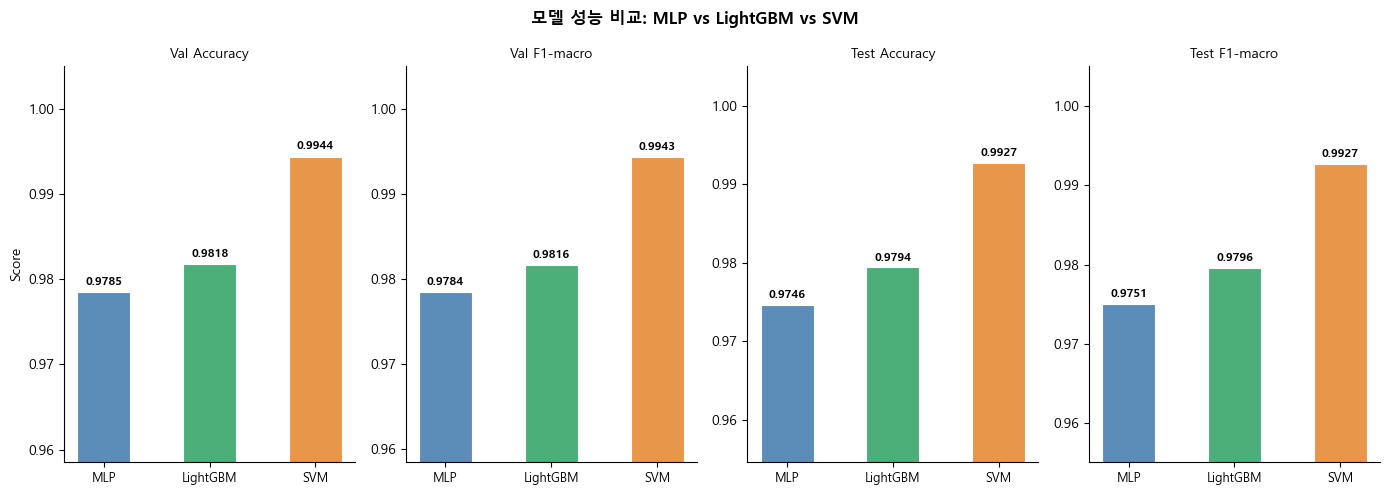

In [4]:
# 전체 지표 막대 비교
metric_labels = {
    'val_accuracy':  'Val Accuracy',
    'val_f1_macro':  'Val F1-macro',
    'test_accuracy': 'Test Accuracy',
    'test_f1_macro': 'Test F1-macro',
}
colors = ['#5B8DB8', '#4CAF7A', '#E8964A']

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=False)
x = np.arange(len(models))

for ax, (col, label) in zip(axes, metric_labels.items()):
    vals = [r[col] for r in results]
    bars = ax.bar(x, vals, width=0.5, color=colors, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=9)
    ax.set_ylim(min(vals) - 0.02, 1.005)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('Score' if ax == axes[0] else '')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('모델 성능 비교: MLP vs LightGBM vs SVM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_bar.png', dpi=150)
plt.show()


## [단계 4] 클래스별 Test 지표 비교

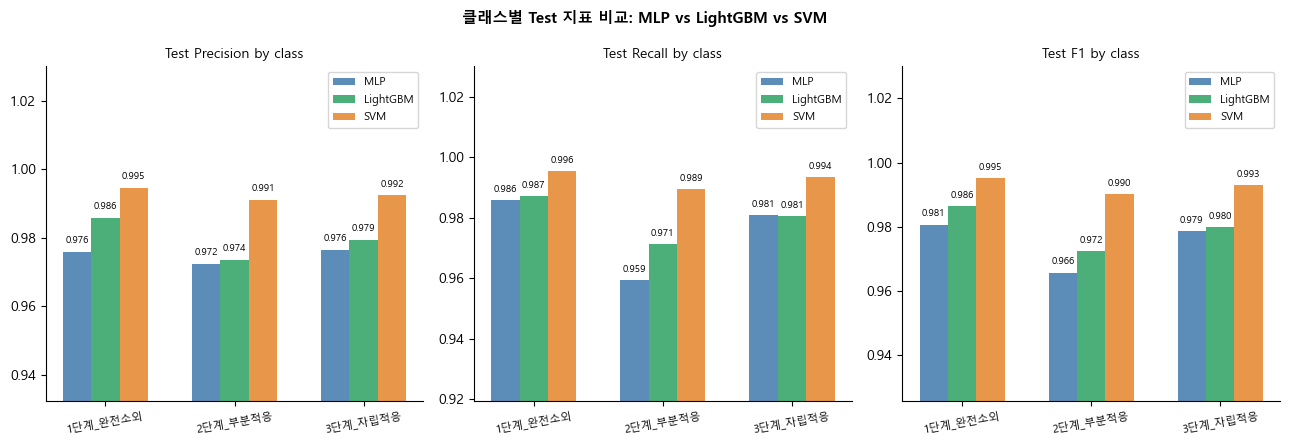

In [5]:
cls_labels = ['1단계_완전소외', '2단계_부분적응', '3단계_자립적응']
metric_list = ['precision', 'recall', 'f1']

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
x     = np.arange(3)
width = 0.22

for ax, metric in zip(axes, metric_list):
    mlp_vals  = [mlp_results['test_per_class'][c][metric]  for c in [0,1,2]]
    lgbm_vals = [lgbm_results['test_per_class'][c][metric] for c in [0,1,2]]
    svm_vals  = [svm_results['test_per_class'][c][metric]  for c in [0,1,2]]

    b1 = ax.bar(x - width, mlp_vals,  width, label='MLP',      color='#5B8DB8')
    b2 = ax.bar(x,         lgbm_vals, width, label='LightGBM', color='#4CAF7A')
    b3 = ax.bar(x + width, svm_vals,  width, label='SVM',      color='#E8964A')

    for bars in [b1, b2, b3]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.002,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(cls_labels, fontsize=8, rotation=10)
    ax.set_ylim(min(min(mlp_vals), min(lgbm_vals), min(svm_vals)) - 0.04, 1.03)
    ax.set_title(f'Test {metric.capitalize()} by class', fontsize=10)
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('클래스별 Test 지표 비교: MLP vs LightGBM vs SVM',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_perclass.png', dpi=150)
plt.show()


## [단계 5] 최종 요약 테이블

In [6]:
summary_rows = []
for m, r in zip(models, results):
    summary_rows.append({
        '모델':           m,
        'Val Accuracy':  f"{r['val_accuracy']:.4f}",
        'Val F1-macro':  f"{r['val_f1_macro']:.4f}",
        'Test Accuracy': f"{r['test_accuracy']:.4f}",
        'Test F1-macro': f"{r['test_f1_macro']:.4f}",
    })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_DIR / 'final_model_summary.csv', index=False, encoding='utf-8-sig')
display(summary_df)


,모델,Val Accuracy,Val F1-macro,Test Accuracy,Test F1-macro
0,MLP,0.9785,0.9784,0.9746,0.9751
1,LightGBM,0.9818,0.9816,0.9794,0.9796
2,SVM,0.9944,0.9943,0.9927,0.9927


## 종합 해석

**성능 순위 (Test F1-macro 기준)**

| 순위 | 모델 | 특징 |
|------|------|------|
| 1위 | SVM | LinearSVC 선형 분류기. 스케일된 feature 공간에서 강한 마진 최적화 |
| 2위 | LightGBM | 트리 앙상블. 비선형 상호작용 학습, feature importance 해석 직관적 |
| 3위 | MLP | 딥러닝. Two-Stage 보정 실험으로 경계 샘플 문제 추가 개선 |

**세 모델 모두 97% 이상의 높은 성능을 보이며 실사용 가능한 수준임.**

**2단계(부분적응) recall이 세 모델 모두에서 상대적으로 낮음:**
- 1단계↔2단계 경계가 모호한 샘플이 가장 분류하기 어려운 케이스
- MLP의 Two-Stage Reclassification이 이 문제를 부분적으로 해결한 접근
- SVM/LightGBM에도 유사한 경계 보정 기법 적용 가능

**모델 선택 기준:**
- **해석 가능성 우선:** LightGBM (feature importance, SHAP 연동 용이)
- **성능 우선:** SVM 또는 LightGBM (test F1 기준)
- **경계 샘플 보정 필요:** MLP Two-Stage 방식 참고
